# นำเข้าข้อมูล

In [4]:
import pandas as pd

# 1. ใส่ลิงก์พัทยา
url_pattaya = 'https://raw.githubusercontent.com/natthaphonmint/wave_prediction_project/refs/heads/main/wave_data/Pattaya_Chonburi_Data.csv'

# 2. ตอนอ่านข้อมูล ให้ใช้ "ชื่อตัวแปรเดิม" ของคุณ (อย่าใช้ df_cha_am)
PattayaChonburi = pd.read_csv(url_pattaya)

# 3. ลองแสดงผล
PattayaChonburi.head()

,Time,Significant height of\ncombined wind waves and swell,Significant height of total swell,Significant height of wind waves,10m u-component of wind,10m v-component of wind,Instantaneous 10m wind gust,Mean wave direction,Mean wave period,2m temperature,Sea surface temperature
0,1/1/2018 0.00,0.626174,0.235719,0.578863,-5.795697,-4.277206,10.830837,47.344345,3.205484,297.070068,299.440185
1,1/1/2018 1.00,0.640214,0.234743,0.594244,-5.745222,-4.430247,10.893438,49.881454,3.256019,296.852539,299.440185
2,1/1/2018 2.00,0.645858,0.256592,0.590584,-5.315084,-4.519053,10.473410,51.178757,3.300434,297.052978,299.440185
3,1/1/2018 3.00,0.625956,0.319089,0.535166,-4.303744,-4.643413,9.248437,51.120972,3.330271,297.359863,299.440185
4,1/1/2018 4.00,0.585083,0.383175,0.440685,-3.140223,-4.817276,8.092788,50.235138,3.335585,297.833984,299.440185


In [6]:
display(f"Start date: {PattayaChonburi .index.min()}")
display(f"End date: {PattayaChonburi .index.max()}")

'Start date: 0'

'End date: 71543'

# การทำความสะอาดข้อมูลและเตรียมข้อมูล

In [7]:
!pip install missingno

<Axes: >

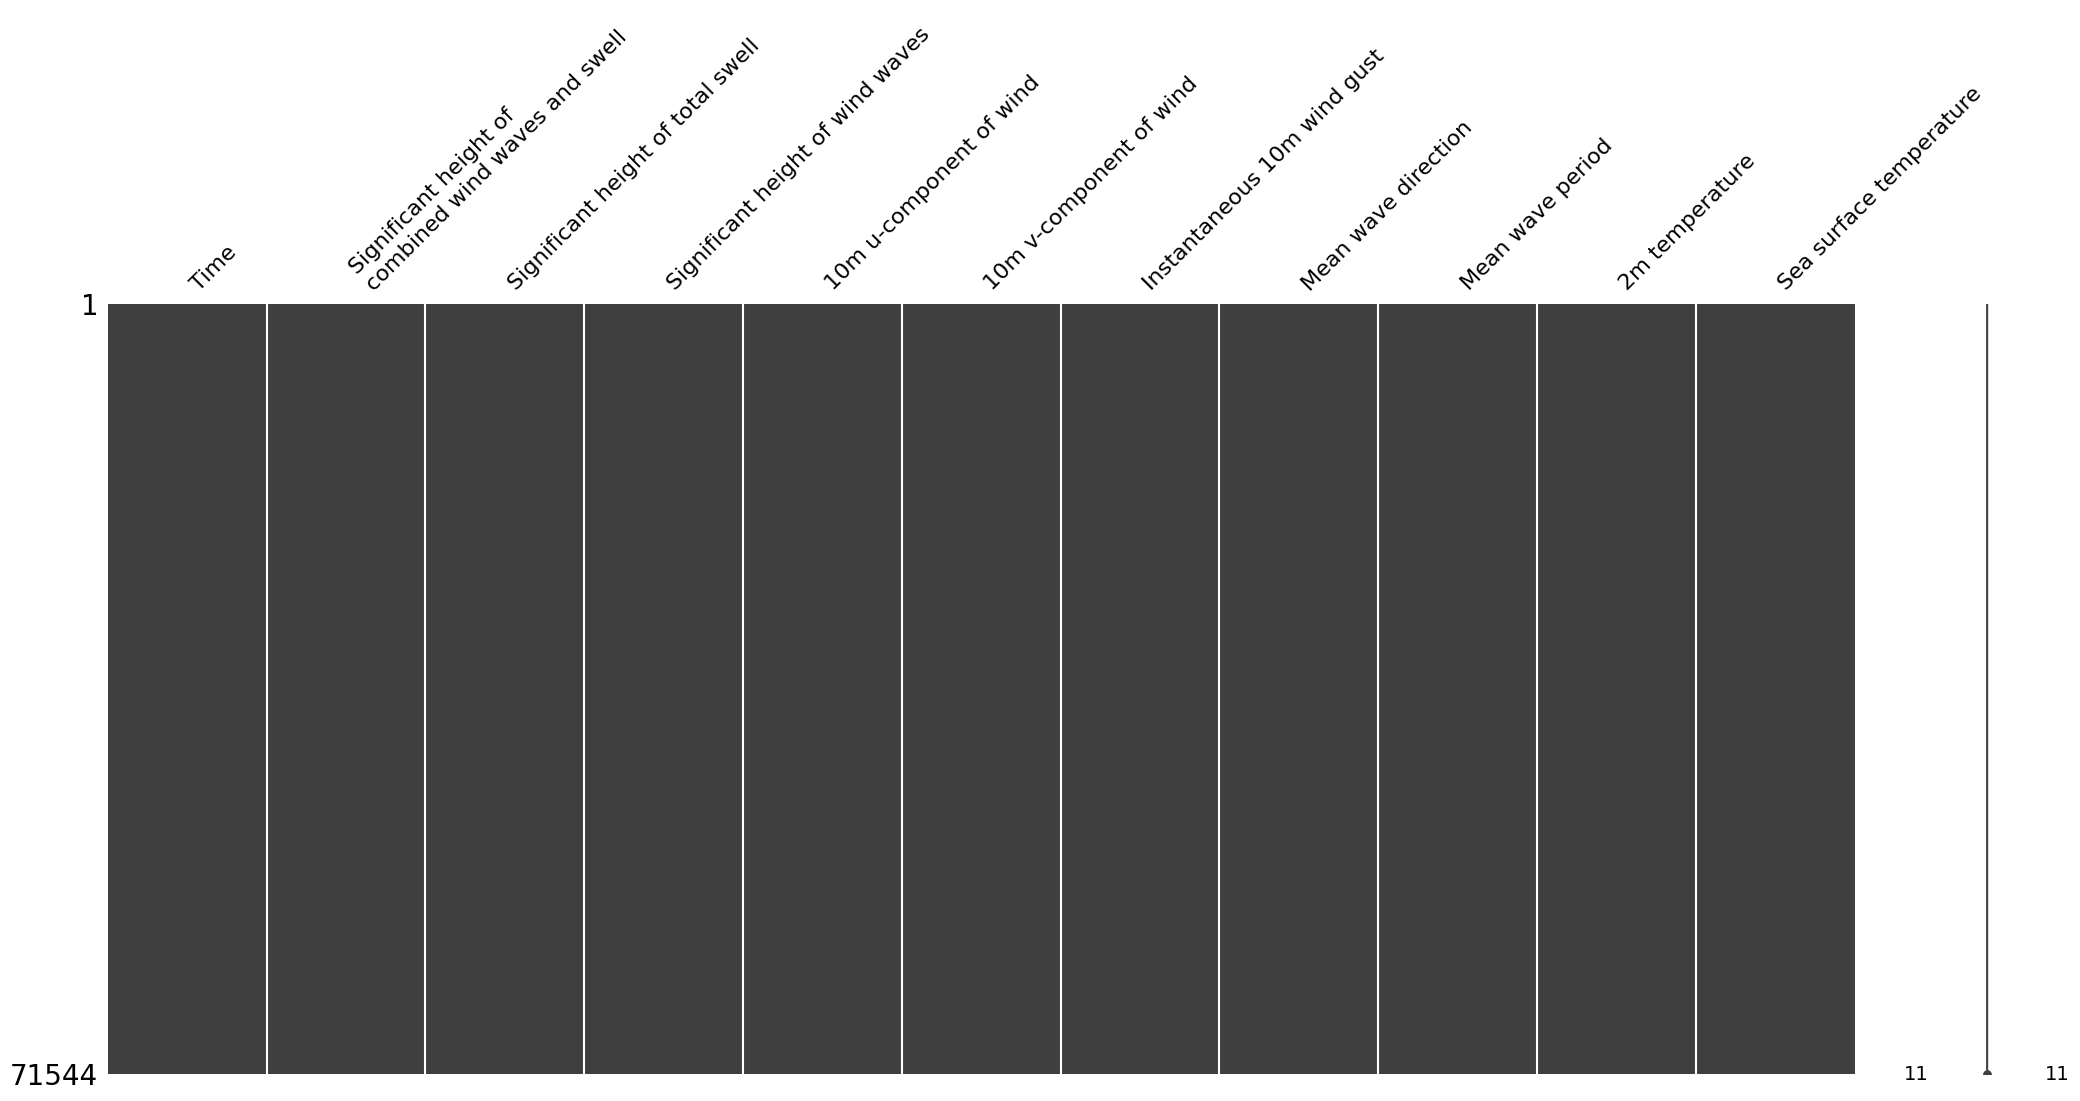

In [8]:
import missingno as msno
msno.matrix(PattayaChonburi)

In [10]:
# Check for missing values
missing_values = PattayaChonburi.isnull().sum()
display("Missing values in each column:")
display(missing_values)

# Display concise summary of the DataFrame, including the number of non-null entries
display(PattayaChonburi.info())

'Missing values in each column:'

,0
Time,0
Significant height of\ncombined wind waves and swell,0
Significant height of total swell,0
Significant height of wind waves,0
10m u-component of wind,0
10m v-component of wind,0
Instantaneous 10m wind gust,0
Mean wave direction,0
Mean wave period,0
2m temperature,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71544 entries, 0 to 71543
Data columns (total 11 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   Time                                                 71544 non-null  object 
 1   Significant height of
combined wind waves and swell  71544 non-null  float64
 2   Significant height of total swell                    71544 non-null  float64
 3   Significant height of wind waves                     71544 non-null  float64
 4   10m u-component of wind                              71544 non-null  float64
 5   10m v-component of wind                              71544 non-null  float64
 6   Instantaneous 10m wind gust                          71544 non-null  float64
 7   Mean wave direction                                  71544 non-null  float64
 8   Mean wave period                                     71544 non-nul

None

คอลัมน์ทั้ง 10 คอลัมน์ ไม่มีค่าที่หายไป

In [11]:
# กำหนดให้คอลัมน์ 'Time' เป็น Index ของ DataFrame และแปลงเป็น DatetimeIndex
# สร้าง DataFrame ใหม่เพื่อหลีกเลี่ยง SettingWithCopyWarning
PattayaChonburi_temp = PattayaChonburi.copy()

# ตรวจสอบรูปแบบเวลาและแทนที่ '.00' ด้วย ':00' หากมี เพื่อให้เป็นรูปแบบมาตรฐาน (H:MM)
PattayaChonburi_temp['Time'] = PattayaChonburi_temp['Time'].str.replace('.00', ':00', regex=False)

PattayaChonburi_indexed = PattayaChonburi_temp.set_index('Time')

# ใช้ format='mixed' และ dayfirst=True เพื่อให้ pandas พยายามเดารูปแบบที่หลากหลาย
PattayaChonburi_indexed.index = pd.to_datetime(PattayaChonburi_indexed.index, format='mixed', dayfirst=True)

# แสดงข้อความและ 5 แถวแรกของ DataFrame เพื่อให้เห็นว่าคอลัมน์ 'Time' ได้กลายเป็น Index
display("DataFrame with 'Time' as datetime index:")
display(PattayaChonburi_indexed.head())

# แสดงชนิดข้อมูลของแต่ละคอลัมน์
display("Data types including index type:")
display(PattayaChonburi_indexed.dtypes)

"DataFrame with 'Time' as datetime index:"

,Significant height of\ncombined wind waves and swell,Significant height of total swell,Significant height of wind waves,10m u-component of wind,10m v-component of wind,Instantaneous 10m wind gust,Mean wave direction,Mean wave period,2m temperature,Sea surface temperature
Time,,,,,,,,,,
2018-01-01 00:00:00,0.626174,0.235719,0.578863,-5.795697,-4.277206,10.830837,47.344345,3.205484,297.070068,299.440185
2018-01-01 01:00:00,0.640214,0.234743,0.594244,-5.745222,-4.430247,10.893438,49.881454,3.256019,296.852539,299.440185
2018-01-01 02:00:00,0.645858,0.256592,0.590584,-5.315084,-4.519053,10.473410,51.178757,3.300434,297.052978,299.440185
2018-01-01 03:00:00,0.625956,0.319089,0.535166,-4.303744,-4.643413,9.248437,51.120972,3.330271,297.359863,299.440185
2018-01-01 04:00:00,0.585083,0.383175,0.440685,-3.140223,-4.817276,8.092788,50.235138,3.335585,297.833984,299.440185


'Data types including index type:'

,0
Significant height of\ncombined wind waves and swell,float64
Significant height of total swell,float64
Significant height of wind waves,float64
10m u-component of wind,float64
10m v-component of wind,float64
Instantaneous 10m wind gust,float64
Mean wave direction,float64
Mean wave period,float64
2m temperature,float64
Sea surface temperature,float64


In [13]:
# ตรวจสอบ time difference ระหว่างแถวที่ติดกัน
time_diff = PattayaChonburi_indexed.index.to_series().diff().dropna()

# สร้างเวกเตอร์ของ time difference
time_diff_vector = time_diff.values

# ตรวจสอบว่า time difference ทั้งหมดเท่ากับ 1 ชั่วโมงหรือไม่
# เนื่องจาก time_diff เป็น TimedeltaIndex, เราสามารถเปรียบเทียบกับ pd.Timedelta(hours=1)
is_one_hour = (time_diff == pd.Timedelta(hours=1))

# ตรวจสอบว่ามีค่าใดที่ไม่เท่ากับ 1 ชั่วโมงหรือไม่
if not is_one_hour.all():
    display("พบความแตกต่างของเวลาที่ไม่เท่ากับ 1 ชั่วโมง:")
    display(time_diff[~is_one_hour])
else:
    display("ความแตกต่างของเวลาในแต่ละแถวเท่ากับ 1 ชั่วโมงทั้งหมด")

    display("ตารางแสดงความแตกต่างของเวลาในแต่ละแถว:")
display(time_diff.head())
display("...")
display(time_diff.tail())

'ความแตกต่างของเวลาในแต่ละแถวเท่ากับ 1 ชั่วโมงทั้งหมด'

'ตารางแสดงความแตกต่างของเวลาในแต่ละแถว:'

,Time
Time,
2018-01-01 01:00:00,0 days 01:00:00
2018-01-01 02:00:00,0 days 01:00:00
2018-01-01 03:00:00,0 days 01:00:00
2018-01-01 04:00:00,0 days 01:00:00
2018-01-01 05:00:00,0 days 01:00:00


'...'

,Time
Time,
2026-02-28 19:00:00,0 days 01:00:00
2026-02-28 20:00:00,0 days 01:00:00
2026-02-28 21:00:00,0 days 01:00:00
2026-02-28 22:00:00,0 days 01:00:00
2026-02-28 23:00:00,0 days 01:00:00


In [14]:
# Check for duplicate rows
duplicate_rows = PattayaChonburi[PattayaChonburi.duplicated()]

if duplicate_rows.empty:
    display("ไม่มีแถวที่ซ้ำกันในข้อมูล")
else:
    display("พบแถวที่ซ้ำกันในข้อมูล:")
    display(duplicate_rows)

'ไม่มีแถวที่ซ้ำกันในข้อมูล'

In [15]:
# ตรวจสอบว่ามี "เวลา" (ซึ่งเป็น Index) ซ้ำซ้อนกันหรือไม่
index_duplicates = PattayaChonburi_indexed.index.duplicated()

if not index_duplicates.any():
    display("ไม่พบแถวข้อมูลที่มี 'เวลาซ้ำซ้อน' (Unique Timestamps)")
    display("ทุกจุดเวลาในชุดข้อมูลนี้มีข้อมูลเพียงชุดเดียว")
else:
    display("พบแถวข้อมูลที่มี 'เวลาซ้ำซ้อน' (Duplicate Timestamps)!")

    # แสดงให้เห็นว่าเวลาไหนที่ซ้ำ
    duplicate_times = PattayaChonburi_indexed.index[index_duplicates].unique()
    display(f"พบเวลาที่ซ้ำซ้อนกัน {len(duplicate_times)} จุดเวลา:")
    display(duplicate_times)

    # แสดงแถวที่ซ้ำทั้งหมด (ทั้งแถวเก่าและแถวใหม่ที่ซ้ำกัน)
    display("แถวข้อมูลทั้งหมดที่มีเวลาซ้ำซ้อนกัน:")
    display(PattayaChonburi_indexed[PattayaChonburi_indexed.index.duplicated(keep=False)])

"ไม่พบแถวข้อมูลที่มี 'เวลาซ้ำซ้อน' (Unique Timestamps)"

'ทุกจุดเวลาในชุดข้อมูลนี้มีข้อมูลเพียงชุดเดียว'